In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

import numpy as np

In [2]:
DATASET_PATH = "../dataset/bccc-cpacket-cloud-ddos-2024-merged.parquet"
df = pd.read_parquet(DATASET_PATH)

# Removing activity columns

In [3]:
df = df.drop(columns=['activity'])

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 540494 entries, 0 to 540493
Columns: 318 entries, src_port to label
dtypes: float32(261), int16(9), int32(20), int64(2), int8(25), str(1)
memory usage: 617.1 MB


In [5]:
df.shape

(540494, 318)

In [6]:
string_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
string_cols

['label']

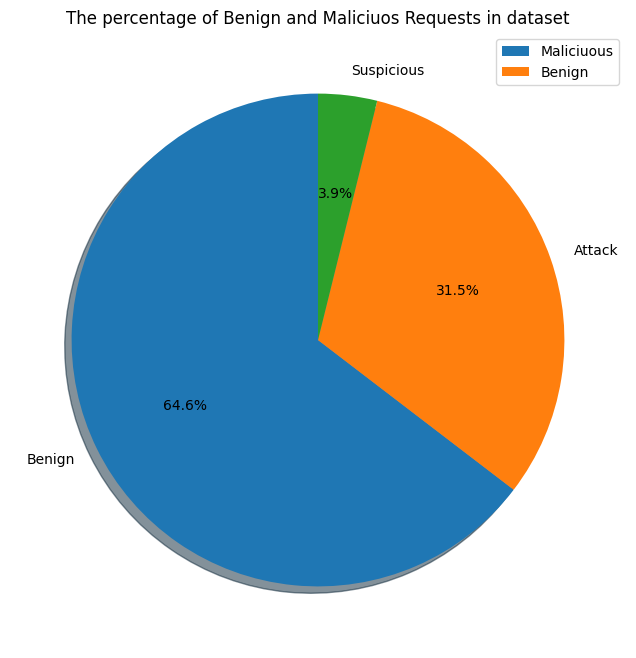

In [7]:
counts_dict = dict(df.label.value_counts())

labels = ["Benign", "Attack", "Suspicious"]
sizes = [
    counts_dict["Benign"], 
    counts_dict["Attack"],
    counts_dict["Suspicious"]
]
plt.figure(figsize = (13,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
plt.legend(["Maliciuous", "Benign"])
plt.title('The percentage of Benign and Maliciuos Requests in dataset')
plt.show()

## Convert labels into numerical

In [8]:
le = LabelEncoder()

In [9]:
df['label'].value_counts()

label
Benign        349178
Attack        170436
Suspicious     20880
Name: count, dtype: int64

In [10]:
df['label'] = le.fit_transform(df['label'])

Benign(1)        349178 <br>
Attack(0)        170436 <br>
Suspicious(2)     20880 <br>

In [11]:
df['label'].value_counts()

label
1    349178
0    170436
2     20880
Name: count, dtype: int64

## Dataset splitting

In [12]:
X = df.drop(columns=['label'])
y = df['label']

In [13]:
print(X.columns)

Index(['src_port', 'dst_port', 'duration', 'packets_count',
       'fwd_packets_count', 'bwd_packets_count', 'total_payload_bytes',
       'fwd_total_payload_bytes', 'bwd_total_payload_bytes',
       'payload_bytes_max',
       ...
       'cov_bwd_payload_bytes_delta_len', 'min_fwd_payload_bytes_delta_len',
       'max_fwd_payload_bytes_delta_len', 'mean_fwd_payload_bytes_delta_len',
       'mode_fwd_payload_bytes_delta_len',
       'variance_fwd_payload_bytes_delta_len',
       'std_fwd_payload_bytes_delta_len', 'median_fwd_payload_bytes_delta_len',
       'skewness_fwd_payload_bytes_delta_len',
       'cov_fwd_payload_bytes_delta_len'],
      dtype='str', length=317)


In [14]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

In [15]:
# 1) Remove zero-variance features (based on train)
zero_var_cols = [col for col in X_train.columns if X_train[col].nunique(dropna=False) <= 1]
if zero_var_cols:
    X_train = X_train.drop(columns=zero_var_cols)
    X_val   = X_val.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)
print(f"[Prep] Dropped {len(zero_var_cols)} zero-variance columns.")

# 2) Remove highly correlated features (>0.95)
import numpy as np
sample_n = min(50_000, len(X_train))
corr_sample = X_train.sample(n=sample_n, random_state=42)
corr_matrix = corr_sample.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
if high_corr_cols:
    X_train = X_train.drop(columns=high_corr_cols)
    X_val   = X_val.drop(columns=high_corr_cols)
    X_test  = X_test.drop(columns=high_corr_cols)
print(f"[Prep] Dropped {len(high_corr_cols)} highly-correlated columns (>0.95).")

feature_columns = list(X_train.columns)
print(f"Final Feature Space: {len(feature_columns)} columns")

[Prep] Dropped 3 zero-variance columns.
[Prep] Dropped 169 highly-correlated columns (>0.95).
Final Feature Space: 145 columns


## Scaling 

In [16]:
scaler = RobustScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

### PCA 

In [18]:
print("\n[PCA] Fitting — retaining 95% of variance...")
pca = PCA(n_components=0.95, random_state=42, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)

n_components = pca.n_components_
variance_retained = sum(pca.explained_variance_ratio_) * 100
print(f"[PCA] Original features:   {X_train_scaled.shape[1]}")
print(f"[PCA] Components retained: {n_components}")
print(f"[PCA] Variance retained:   {variance_retained:.2f}%")
print(f"[PCA] Dimensionality reduction: {X_train_scaled.shape[1]}→{n_components} "
      f"({100 - X_train_scaled.shape[1]/n_components*100:.0f}% fewer dims)")


[PCA] Fitting — retaining 95% of variance...
[PCA] Original features:   145
[PCA] Components retained: 2
[PCA] Variance retained:   98.66%
[PCA] Dimensionality reduction: 145→2 (-7150% fewer dims)


## Modeling

In [19]:
model = KNeighborsClassifier(
    n_neighbors=11,
    weights='distance',         # Distance-weighted votes — key for imbalance
    algorithm='ball_tree',      # Faster than brute force; best after PCA
    leaf_size=40,               # Larger leaf = less memory, slightly slower queries
    metric='euclidean',         # Standard L2 — valid after StandardScaler+PCA
    n_jobs=-1,                  # Parallelize across all CPU cores
)

In [20]:
print(f"\n[KNN] Fitting on {X_train_pca.shape[0]:,} rows × "
      f"{X_train_pca.shape[1]} PCA components...")
model.fit(X_train_pca, y_train)
print("[KNN] Fit complete.")


[KNN] Fitting on 324,296 rows × 2 PCA components...
[KNN] Fit complete.


## Evaluation 

In [21]:
print("\n[KNN] Predicting on test set (this may take a moment)...")
y_pred_encoded = model.predict(X_test_pca)
y_pred_labels  = le.inverse_transform(y_pred_encoded)
y_test_labels  = le.inverse_transform(y_test)


[KNN] Predicting on test set (this may take a moment)...


In [22]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_labels, y_pred_labels, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Attack     0.5849    0.8572    0.6954     34087
      Benign     0.8958    0.7310    0.8050     69836
  Suspicious     0.2550    0.0709    0.1109      4176

    accuracy                         0.7453    108099
   macro avg     0.5786    0.5530    0.5371    108099
weighted avg     0.7730    0.7453    0.7436    108099



In [23]:
# Why these metrics matter:
# Accuracy:    MISLEADING — 64.6% for free by always predicting Benign
# Macro F1:    Equal weight per class → penalizes poor Suspicious detection
# Weighted F1: Weighted by support → overall system health indicator
macro_f1    = f1_score(y_test_labels, y_pred_labels, average='macro')
weighted_f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')
print("KEY METRICS:")
print(f"  Macro F1:    {macro_f1:.4f}  ← Primary (sensitive to rare classes)")
print(f"  Weighted F1: {weighted_f1:.4f}  ← Secondary (overall system health)")

KEY METRICS:
  Macro F1:    0.5371  ← Primary (sensitive to rare classes)
  Weighted F1: 0.7436  ← Secondary (overall system health)


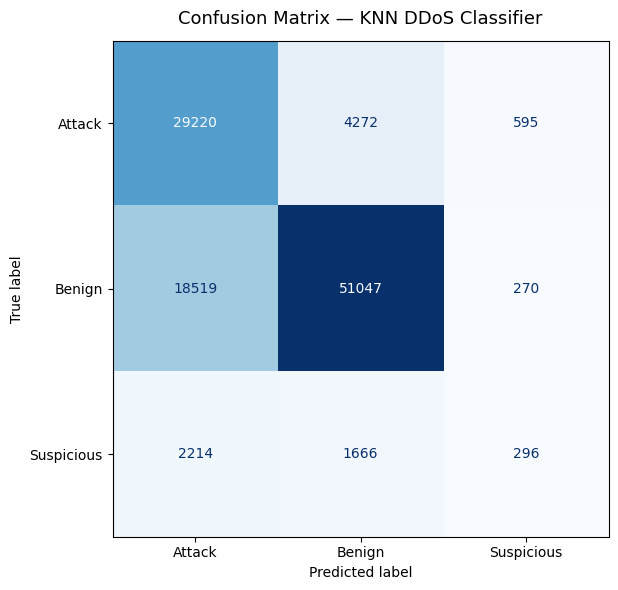


[Output] Confusion matrix saved → knn_confusion_matrix.png


In [24]:
# ── 10. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=le.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Confusion Matrix — KNN DDoS Classifier", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("knn_confusion_matrix.png", dpi=150)
plt.show()
print("\n[Output] Confusion matrix saved → knn_confusion_matrix.png")

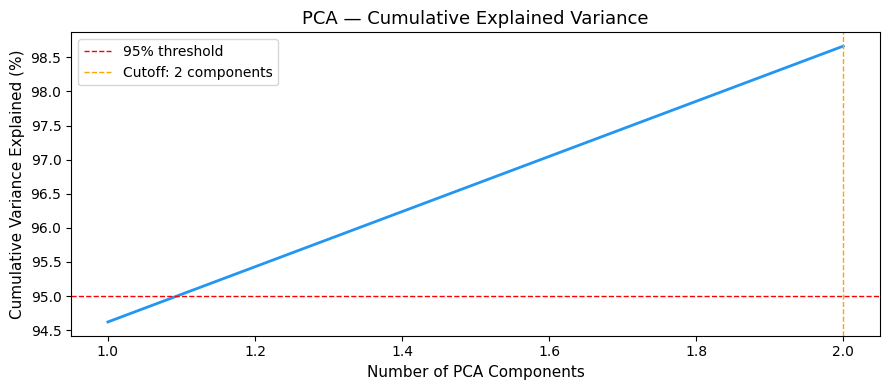

[Output] PCA variance plot saved → knn_pca_variance.png

✓ Pipeline complete.


In [25]:
# ── 11. PCA EXPLAINED VARIANCE PLOT ───────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar, color='#2196F3', linewidth=2)
ax.axhline(95, color='red', linestyle='--', linewidth=1, label='95% threshold')
ax.axvline(n_components, color='orange', linestyle='--', linewidth=1,
           label=f'Cutoff: {n_components} components')
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
ax.set_title("PCA — Cumulative Explained Variance", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("knn_pca_variance.png", dpi=150)
plt.show()
print("[Output] PCA variance plot saved → knn_pca_variance.png")

print("\n✓ Pipeline complete.")

In [26]:
import joblib 

model_filename = 'knn_model.joblib'
joblib.dump(model, model_filename)
print(f"[Output] Trained model saved to '{model_filename}'")

[Output] Trained model saved to 'knn_model.joblib'


In [27]:
preprocess_info = {
    "zero_var_cols": zero_var_cols,
    "high_corr_cols": high_corr_cols,
    "feature_columns": feature_columns,
    "scaler": scaler,
    "pca": pca
}
joblib.dump(preprocess_info, "knn_preprocess_info.joblib")
print("Preprocessing info saved to knn_preprocess_info.joblib")


Preprocessing info saved to knn_preprocess_info.joblib


In [31]:
models = [
    'knn_preprocess_info.joblib',
    'logisticRegression_preprocess_info.joblib',
    'randomForest_preprocess_info.joblib',
    'svm_preprocess_info.joblib',
    'xgboost_preprocess_info.joblib'
]


for model in models:
    print(f"Loading {model}...")
    info = joblib.load(model)
    print(f"  Feature columns: {len(info['feature_columns'])}")
    print(f"  Zero-variance columns: {len(info['zero_var_cols'])}")
    print(f"  Highly-correlated columns: {len(info['high_corr_cols'])}")

Loading knn_preprocess_info.joblib...
  Feature columns: 145
  Zero-variance columns: 3
  Highly-correlated columns: 169
Loading logisticRegression_preprocess_info.joblib...
  Feature columns: 162
  Zero-variance columns: 3
  Highly-correlated columns: 152
Loading randomForest_preprocess_info.joblib...
  Feature columns: 317
  Zero-variance columns: 3
  Highly-correlated columns: 152
Loading svm_preprocess_info.joblib...
  Feature columns: 145
  Zero-variance columns: 3
  Highly-correlated columns: 169
Loading xgboost_preprocess_info.joblib...
  Feature columns: 317
  Zero-variance columns: 3
  Highly-correlated columns: 152
